In [66]:
# Cell 1: Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import cv2
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [67]:
# Cell 2: Enhanced augmentation class with multiple variations
class EnhancedDrawingAugmentations:
    def __init__(self):
        self.augmentations = {
            'thicken': self.thicken_lines,
            'thin': self.smart_thin_lines,
            'rotate': self.small_rotate,
            'shift': self.shift_image
        }

    def thicken_lines(self, image, kernel_size=3):
        """Make lines bolder using dilation"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        return cv2.dilate(image, kernel, iterations=1)

    def smart_thin_lines(self, image, kernel_size=3):
        """Make lines thinner only if it won't lose information"""
        white_pixels_before = np.sum(image > 128)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        eroded = cv2.erode(image, kernel, iterations=1)
        white_pixels_after = np.sum(eroded > 128)

        if white_pixels_after > 0.7 * white_pixels_before:
            return eroded
        else:
            return image

    def small_rotate(self, image, angle):
        """Rotate image by specific angle"""
        return ndimage.rotate(image, angle, reshape=False, cval=0)

    def shift_image(self, image, shift_x, shift_y):
        """Shift image by specific amounts"""
        h, w = image.shape
        M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        return cv2.warpAffine(image, M, (w, h), borderValue=0)

    def generate_augmented_versions(self, image):
        """Generate multiple augmented versions of an image"""
        augmented_images = []

        # Original image
        augmented_images.append(('original', image.copy()))

        # Thickness variations (3-5 versions)
        # Thicker versions
        for size in [3, 5]:
            aug_img = self.thicken_lines(image.copy(), kernel_size=size)
            augmented_images.append((f'thicken_{size}', aug_img))

        # Thinner versions
        for size in [3]:
            aug_img = self.smart_thin_lines(image.copy(), kernel_size=size)
            augmented_images.append((f'thin_{size}', aug_img))

        # Very slight thickness variation
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        slightly_thick = cv2.dilate(image, kernel, iterations=1)
        augmented_images.append(('slightly_thick', slightly_thick))

        # Rotation variations (3-5 versions)
        for angle in [-5, -3, -2, 2, 3, 5]:
            aug_img = self.small_rotate(image.copy(), angle)
            augmented_images.append((f'rotate_{angle}', aug_img))

        # Shift variations (3-5 versions)
        h, w = image.shape
        shift_amounts = [
            (-int(w*0.05), -int(h*0.05)),  # top-left
            (int(w*0.05), -int(h*0.05)),   # top-right
            (-int(w*0.05), int(h*0.05)),   # bottom-left
            (int(w*0.05), int(h*0.05)),    # bottom-right
            (0, -int(h*0.07)),             # up
            (0, int(h*0.07)),              # down
            (-int(w*0.07), 0),             # left
            (int(w*0.07), 0),              # right
        ]

        for i, (shift_x, shift_y) in enumerate(shift_amounts):
            aug_img = self.shift_image(image.copy(), shift_x, shift_y)
            augmented_images.append((f'shift_{i}', aug_img))

        return augmented_images

In [68]:
# Cell 3: Modified Dataset with heavy augmentation
class HeavilyAugmentedDatasetShape2(Dataset):
    def __init__(self, df, base_path, transform=None, augment_factor=15):
        """
        augment_factor: how many augmented versions to create per image
        """
        # Filter for shape 2 only
        self.df = df[df['shape'] == 2].reset_index(drop=True)
        print(f"Original samples for shape 2: {len(self.df)}")

        self.base_path = base_path
        self.transform = transform
        self.augment_factor = augment_factor
        self.aug = EnhancedDrawingAugmentations()

        # Path to reference image for shape 2
        self.reference_path = os.path.join(base_path, 'shape2', 'original2.png')
        if not os.path.exists(self.reference_path):
            raise FileNotFoundError(f"Reference image not found: {self.reference_path}")

        # Create augmented dataset
        self.augmented_data = []

        for idx, row in tqdm(self.df.iterrows(), total=len(self.df), desc="Creating augmented dataset"):
            child_id = int(row['child_id'])
            score = int(row['score'])

            child_img_path = os.path.join(base_path, 'shape2', f'{child_id}.png')

            if os.path.exists(child_img_path):
                # Load image once
                image = cv2.imread(child_img_path, cv2.IMREAD_GRAYSCALE)

                # Generate augmented versions
                augmented_versions = self.aug.generate_augmented_versions(image)

                # Add original
                self.augmented_data.append({
                    'image': image,
                    'score': score - 1,
                    'child_id': child_id,
                    'aug_type': 'original'
                })

                # Add augmented versions (randomly select up to augment_factor)
                if len(augmented_versions) > 1:
                    # Exclude original, randomly sample from augmentations
                    aug_samples = augmented_versions[1:]
                    np.random.shuffle(aug_samples)

                    for i, (aug_type, aug_img) in enumerate(aug_samples[:self.augment_factor-1]):
                        self.augmented_data.append({
                            'image': aug_img,
                            'score': score - 1,
                            'child_id': child_id,
                            'aug_type': aug_type
                        })

        print(f"Total samples after augmentation: {len(self.augmented_data)}")

        # Count samples per class
        class_counts = {}
        for item in self.augmented_data:
            score = item['score'] + 1
            class_counts[score] = class_counts.get(score, 0) + 1

        print("\nAugmented samples per score:")
        for score in sorted(class_counts.keys()):
            print(f"Score {score}: {class_counts[score]} samples")

    def __len__(self):
        return len(self.augmented_data)

    def __getitem__(self, idx):
        data = self.augmented_data[idx]

        # Get child image (already augmented)
        child_image = data['image']
        score = data['score']

        # Load reference image
        reference_image = cv2.imread(self.reference_path, cv2.IMREAD_GRAYSCALE)

        # Convert to RGB
        child_image = cv2.cvtColor(child_image, cv2.COLOR_GRAY2RGB)
        reference_image = cv2.cvtColor(reference_image, cv2.COLOR_GRAY2RGB)

        # Convert to PIL Image
        child_image = Image.fromarray(child_image)
        reference_image = Image.fromarray(reference_image)

        # Apply transforms
        if self.transform:
            child_image = self.transform(child_image)
            reference_image = self.transform(reference_image)

        return child_image, reference_image, score

In [69]:
# Cell 4: Simple lightweight Siamese network
class SimpleSiameseNetwork(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Simple CNN feature extractor (much lighter than ResNet)
        self.feature_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Simple comparison head
        self.comparison_head = nn.Sequential(
            nn.Linear(256 * 3, 128),  # child features, ref features, difference
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward_one(self, x):
        """Extract features from one image"""
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        return x

    def forward(self, child_img, reference_img):
        # Extract features
        child_features = self.forward_one(child_img)
        ref_features = self.forward_one(reference_img)

        # Compute absolute difference
        diff = torch.abs(child_features - ref_features)

        # Concatenate all features
        combined = torch.cat([child_features, ref_features, diff], dim=1)

        # Final classification
        output = self.comparison_head(combined)

        return output

In [70]:
# Cell 5: Modified training functions for paired inputs
def train_epoch_siamese(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for child_imgs, ref_imgs, labels in tqdm(dataloader, desc="Training"):
        child_imgs = child_imgs.to(device)
        ref_imgs = ref_imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(child_imgs, ref_imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(dataloader), 100 * correct / total

def validate_epoch_siamese(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for child_imgs, ref_imgs, labels in tqdm(dataloader, desc="Validation"):
            child_imgs = child_imgs.to(device)
            ref_imgs = ref_imgs.to(device)
            labels = labels.to(device)

            outputs = model(child_imgs, ref_imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(dataloader), 100 * correct / total, all_predictions, all_labels

In [71]:
# Cell 6: Modified training code with simple model
# Load data
csv_path = r"C:\Users\yozev\PycharmProjects\finetuning\Majority_Score_per_Child_and_Shape.csv"
base_path = r"C:\Users\yozev\OneDrive\Desktop\Shapes2"

df = pd.read_csv(csv_path)

# Filter for shape 2 only
df_shape2 = df[df['shape'] == 2].copy()
print(f"Original samples for shape 2: {len(df_shape2)}")
print(f"Score distribution for shape 2:")
print(df_shape2['score'].value_counts().sort_index())

# Split data BEFORE augmentation
train_df, val_df = train_test_split(df_shape2, test_size=0.2, random_state=42, stratify=df_shape2['score'])
print(f"\nOriginal training samples: {len(train_df)}")
print(f"Original validation samples: {len(val_df)}")

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Smaller input size for simpler model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create heavily augmented training dataset
print("\nCreating augmented training dataset...")
train_dataset = HeavilyAugmentedDatasetShape2(train_df, base_path, transform=train_transform, augment_factor=15)

# Create normal validation dataset (no augmentation)
print("\nCreating validation dataset...")
val_dataset = HeavilyAugmentedDatasetShape2(val_df, base_path, transform=val_transform, augment_factor=1)

# Create dataloaders
batch_size = 64  # Can use larger batch size with simpler model
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Calculate class weights
train_scores = [item['score'] + 1 for item in train_dataset.augmented_data]
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(train_scores), y=train_scores)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"\nClass weights: {class_weights}")

# Initialize simple Siamese model
model = SimpleSiameseNetwork(num_classes=7)
model = model.to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024 / 1024:.2f} MB")

# Define loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with higher learning rate for simpler model
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Simple scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training loop
num_epochs = 100
best_val_acc = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

patience = 20
patience_counter = 0
min_delta = 0.001

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for child_imgs, ref_imgs, labels in tqdm(train_loader, desc="Training"):
        child_imgs = child_imgs.to(device)
        ref_imgs = ref_imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(child_imgs, ref_imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validation
    val_loss, val_acc, val_preds, val_labels = validate_epoch_siamese(model, val_loader, criterion, device)

    # Step scheduler
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_simple_siamese_shape2.pth')
        print(f"Best model saved with validation accuracy: {best_val_acc:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

Original samples for shape 2: 205
Score distribution for shape 2:
score
1    13
2    45
3    37
4    47
5    25
6    30
7     8
Name: count, dtype: int64

Original training samples: 164
Original validation samples: 41

Creating augmented training dataset...
Original samples for shape 2: 164


Creating augmented dataset: 100%|██████████| 164/164 [00:02<00:00, 61.36it/s]


Total samples after augmentation: 2415

Augmented samples per score:
Score 1: 105 samples
Score 2: 540 samples
Score 3: 450 samples
Score 4: 570 samples
Score 5: 300 samples
Score 6: 360 samples
Score 7: 90 samples

Creating validation dataset...
Original samples for shape 2: 41


Creating augmented dataset: 100%|██████████| 41/41 [00:00<00:00, 60.68it/s]


Total samples after augmentation: 41

Augmented samples per score:
Score 1: 3 samples
Score 2: 9 samples
Score 3: 7 samples
Score 4: 9 samples
Score 5: 5 samples
Score 6: 6 samples
Score 7: 2 samples

Training batches: 38
Validation batches: 1

Class weights: tensor([3.2857, 0.6389, 0.7667, 0.6053, 1.1500, 0.9583, 3.8333])

Total parameters: 496,519
Model size: ~1.89 MB

Epoch 1/100


...

Train Loss: 0.2996, Train Acc: 85.67%
Val Loss: 15.8670, Val Acc: 14.63%
Learning Rate: 0.000500

Epoch 41/100


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]


Train Loss: 0.2856, Train Acc: 86.67%
Val Loss: 14.2476, Val Acc: 9.76%
Learning Rate: 0.000500

Epoch 42/100


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]

Train Loss: 0.2901, Train Acc: 86.87%
Val Loss: 8.9941, Val Acc: 12.20%
Learning Rate: 0.000500
Early stopping triggered after 42 epochs


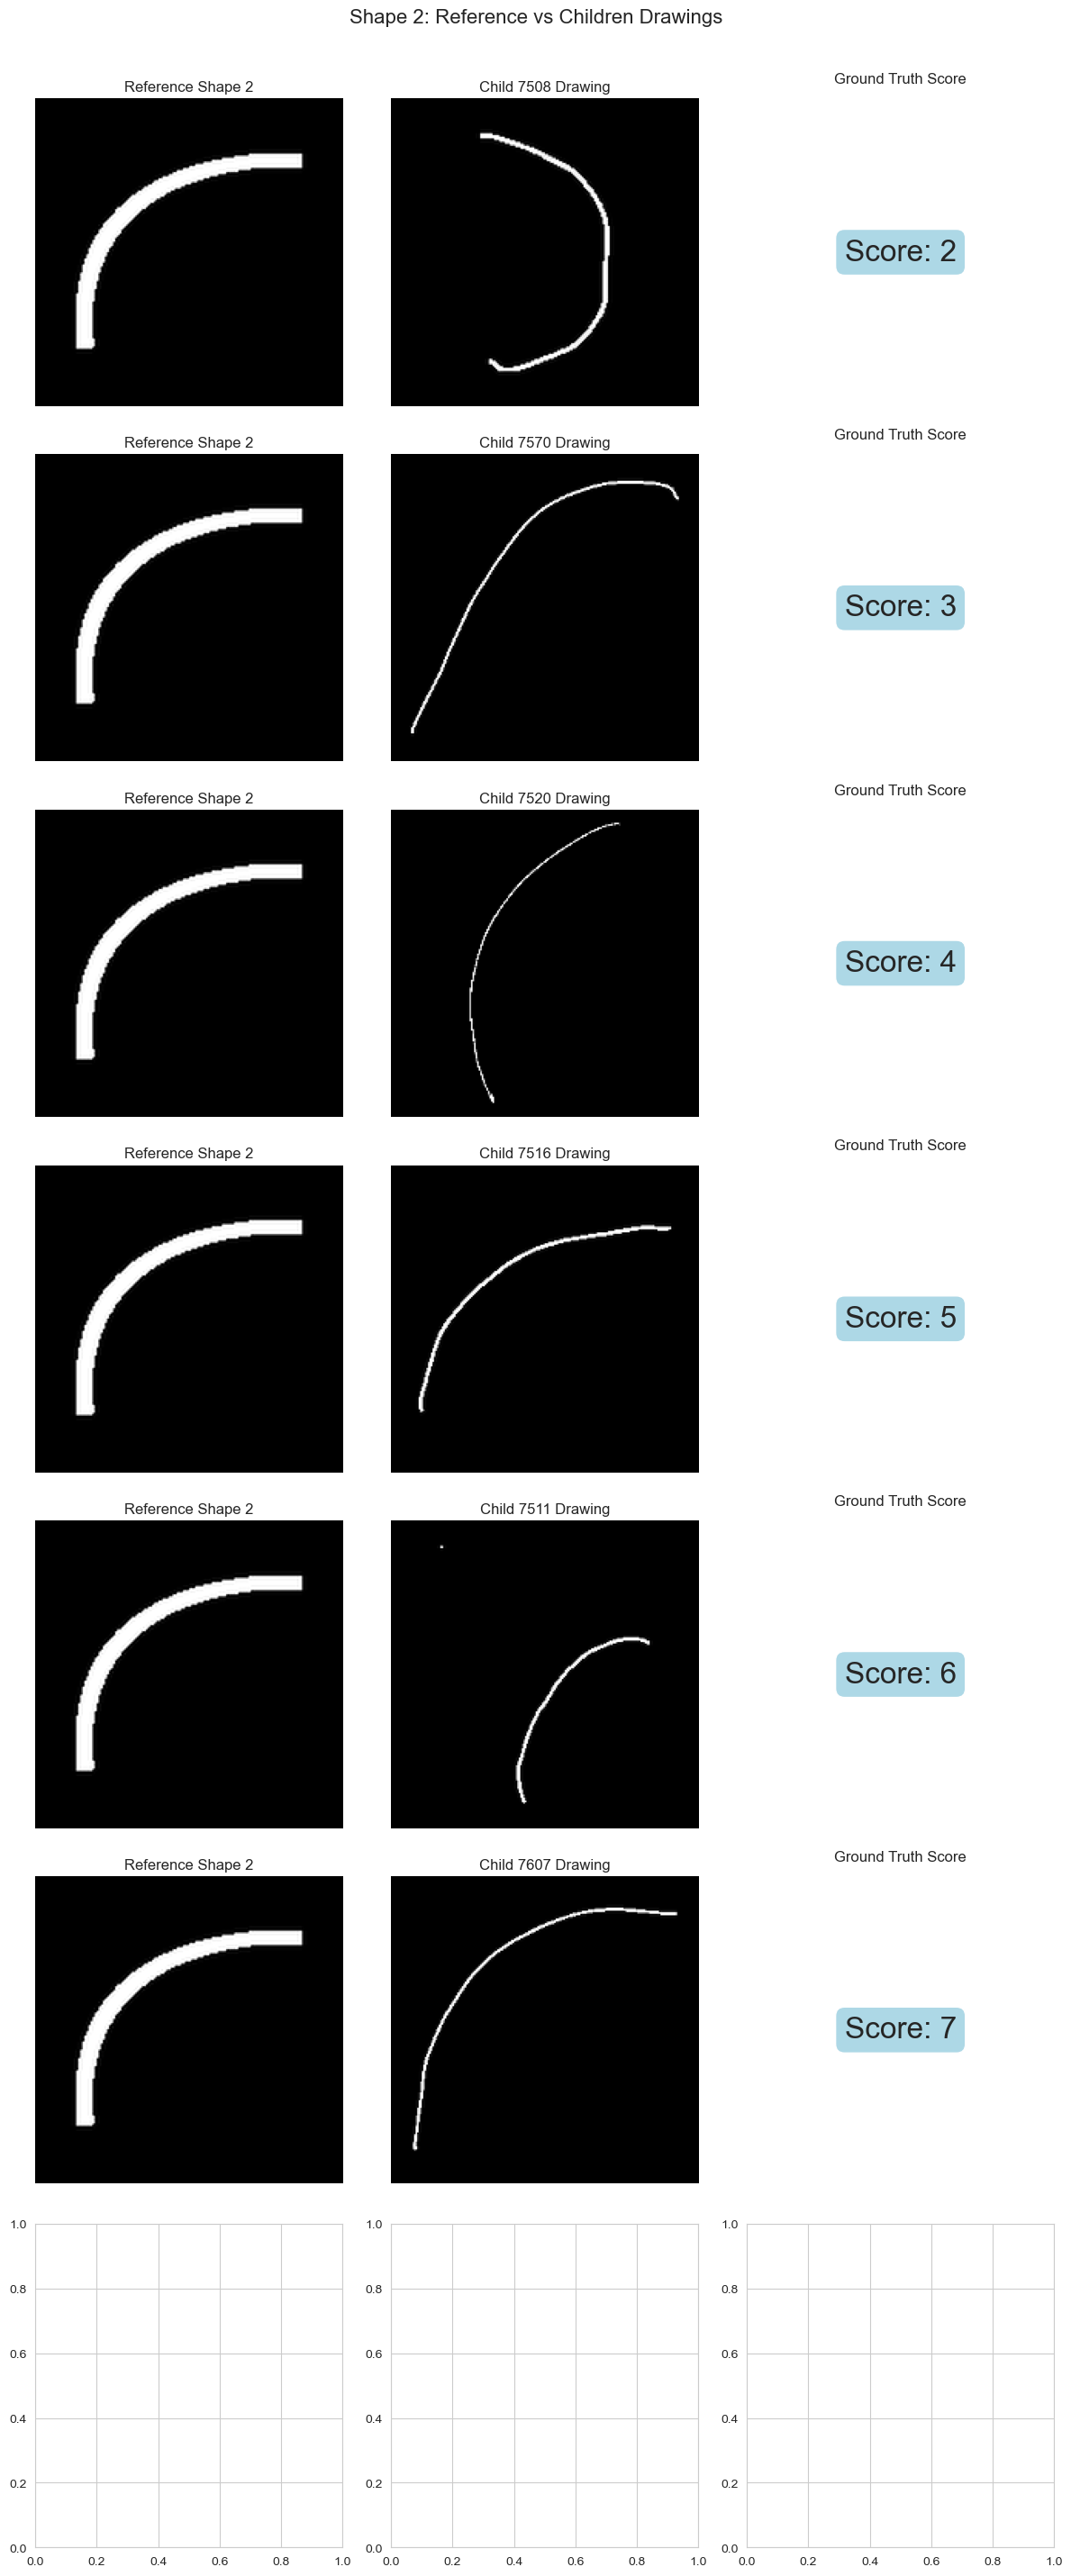

In [72]:
# Cell 7: Visualization function for shape 2 pairs
def visualize_shape2_pairs(csv_path, base_path, num_samples=5):
    df = pd.read_csv(csv_path)
    df_shape2 = df[df['shape'] == 2]

    # Sample different scores
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    # Load reference image once
    reference_img_path = os.path.join(base_path, 'shape2', 'original2.png')
    ref_img = cv2.imread(reference_img_path, cv2.IMREAD_GRAYSCALE)

    samples_shown = 0
    # Try to get diverse scores
    for score in range(1, 8):
        if samples_shown >= num_samples:
            break

        score_samples = df_shape2[df_shape2['score'] == score]
        if len(score_samples) > 0:
            row = score_samples.iloc[0]
            child_id = int(row['child_id'])

            child_img_path = os.path.join(base_path, 'shape2', f'{child_id}.png')
            if os.path.exists(child_img_path):
                child_img = cv2.imread(child_img_path, cv2.IMREAD_GRAYSCALE)

                # Show reference
                axes[samples_shown, 0].imshow(ref_img, cmap='gray')
                axes[samples_shown, 0].set_title('Reference Shape 2')
                axes[samples_shown, 0].axis('off')

                # Show child's drawing
                axes[samples_shown, 1].imshow(child_img, cmap='gray')
                axes[samples_shown, 1].set_title(f'Child {child_id} Drawing')
                axes[samples_shown, 1].axis('off')

                # Show score
                axes[samples_shown, 2].text(0.5, 0.5, f'Score: {score}',
                                            fontsize=24, ha='center', va='center',
                                            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
                axes[samples_shown, 2].set_title('Ground Truth Score')
                axes[samples_shown, 2].axis('off')

                samples_shown += 1

    plt.tight_layout()
    plt.suptitle('Shape 2: Reference vs Children Drawings', fontsize=16, y=1.02)
    plt.show()

# Visualize some pairs
visualize_shape2_pairs(csv_path, base_path, num_samples=7)

In [73]:
# Cell 8: Evaluation and confusion matrix
# Load best model
model.load_state_dict(torch.load('best_drawing_score_model.pth'))

# Get predictions on validation set
_, _, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)

# Convert back to 1-7 scale
val_preds = [p + 1 for p in val_preds]
val_labels = [l + 1 for l in val_labels]

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.xlabel('Predicted Score')
plt.ylabel('True Score')
plt.title('Confusion Matrix for Drawing Scores')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=[f'Score {i}' for i in range(1, 8)]))

RuntimeError: Error(s) in loading state_dict for SimpleSiameseNetwork:
	Missing key(s) in state_dict: "feature_extractor.0.weight", "feature_extractor.0.bias", "feature_extractor.1.weight", "feature_extractor.1.bias", "feature_extractor.1.running_mean", "feature_extractor.1.running_var", "feature_extractor.4.weight", "feature_extractor.4.bias", "feature_extractor.5.weight", "feature_extractor.5.bias", "feature_extractor.5.running_mean", "feature_extractor.5.running_var", "feature_extractor.8.weight", "feature_extractor.8.bias", "feature_extractor.9.weight", "feature_extractor.9.bias", "feature_extractor.9.running_mean", "feature_extractor.9.running_var", "feature_extractor.12.weight", "feature_extractor.12.bias", "feature_extractor.13.weight", "feature_extractor.13.bias", "feature_extractor.13.running_mean", "feature_extractor.13.running_var", "comparison_head.0.weight", "comparison_head.0.bias", "comparison_head.3.weight", "comparison_head.3.bias", "comparison_head.6.weight", "compari

In [44]:
# Cell 9: Inference function
def predict_score(model, image_path, device):
    """Predict score for a single image"""
    model.eval()

    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image = Image.fromarray(image)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
        score = predicted.item() + 1  # Convert back to 1-7 scale

    return score

# Example usage
# score = predict_score(model, r"C:\Users\yozev\OneDrive\Desktop\Shapes2\shape2\7511.png", device)
# print(f"Predicted score: {score}")